# Credit card fruad detection 
* the goal of this project is understand the unabalanced data and data detection in bank format 

* the key concept of the fruad detection execpt of their class is fast transaction or alot of amount transaction that we today we will concider the only class value no time analyst but in real world we consider many factors not just classes 

In [2]:
#! pip  install -r "../requirments.txt"

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split , KFold , GroupKFold , TimeSeriesSplit , StratifiedKFold , GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score , confusion_matrix , f1_score , precision_score , recall_score , roc_auc_score ,classification_report
import xgboost as xgb 
import lightgbm as lgb 
from catboost import CatBoostClassifier


* read the credit data 

*  the number of see is the result of component analysis of features due to the in the trasaction features and make them to these numbers we have in our rows 


# PCA principal component analysis : its method to reduce the dimension of complex featuers as much as it orginal attrebitue of them keep save  for example make 3D to 2D 
* it make datasets with high correlation variable like weights heights  and etc combined and make it to the for example body size 
* order of importance  : the first order has the most variance PC1 and the PC2 secondmost and so on 
* the result of the component analysis is mixed features that are so independed and not correlate 
* we use the  PCA inside the fruad detection first of the security of customers second make high complex features to less correlated and we represent them as **v** 
* benefits : 
 * it removes noise of data 
 * making easier and faster for alghorthim to spot between a normal purchase and a fruadulent one  

In [3]:
# time of transaction are not expose as the security of credit cards app 
# and the time columns shows that the time transaction in a second from first transaction to the last one 
# amount columns are usd dollar that it transaction and it devide it into to class of 0 and 1 in 1 it means its not normal transaction and in 0 its normal
credit_data = pd.read_csv('../datasets/creditcard.csv')
first = credit_data.head(5) 
last = credit_data.tail(5)
first_last = pd.concat([first,last])
# from first second of transaction to the last one that almost 2 days 
first_last

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [5]:
credit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
# no missing values 
credit_data.isnull().sum()
# if ti was any missing values based on outliers and also prediction goal we would use mean median or feature  function 

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

# Dataset manipulation : based on goal of project we try to show and try new datasets to see which method of scaling and feature engineering will represent best value of our main raw datasets 
* note this data is so unablanced we need to for sure scale and saparate it carefully but change the main attrebuites of datta just make fake datasets from it !

* our raw data that we gonna try to change some features inside it 

In [5]:
credit_data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


# visual all columns based on disturbution of them

* if you focus in the class hist plot shows the amount of fruad is that small even we cant see it well

array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <

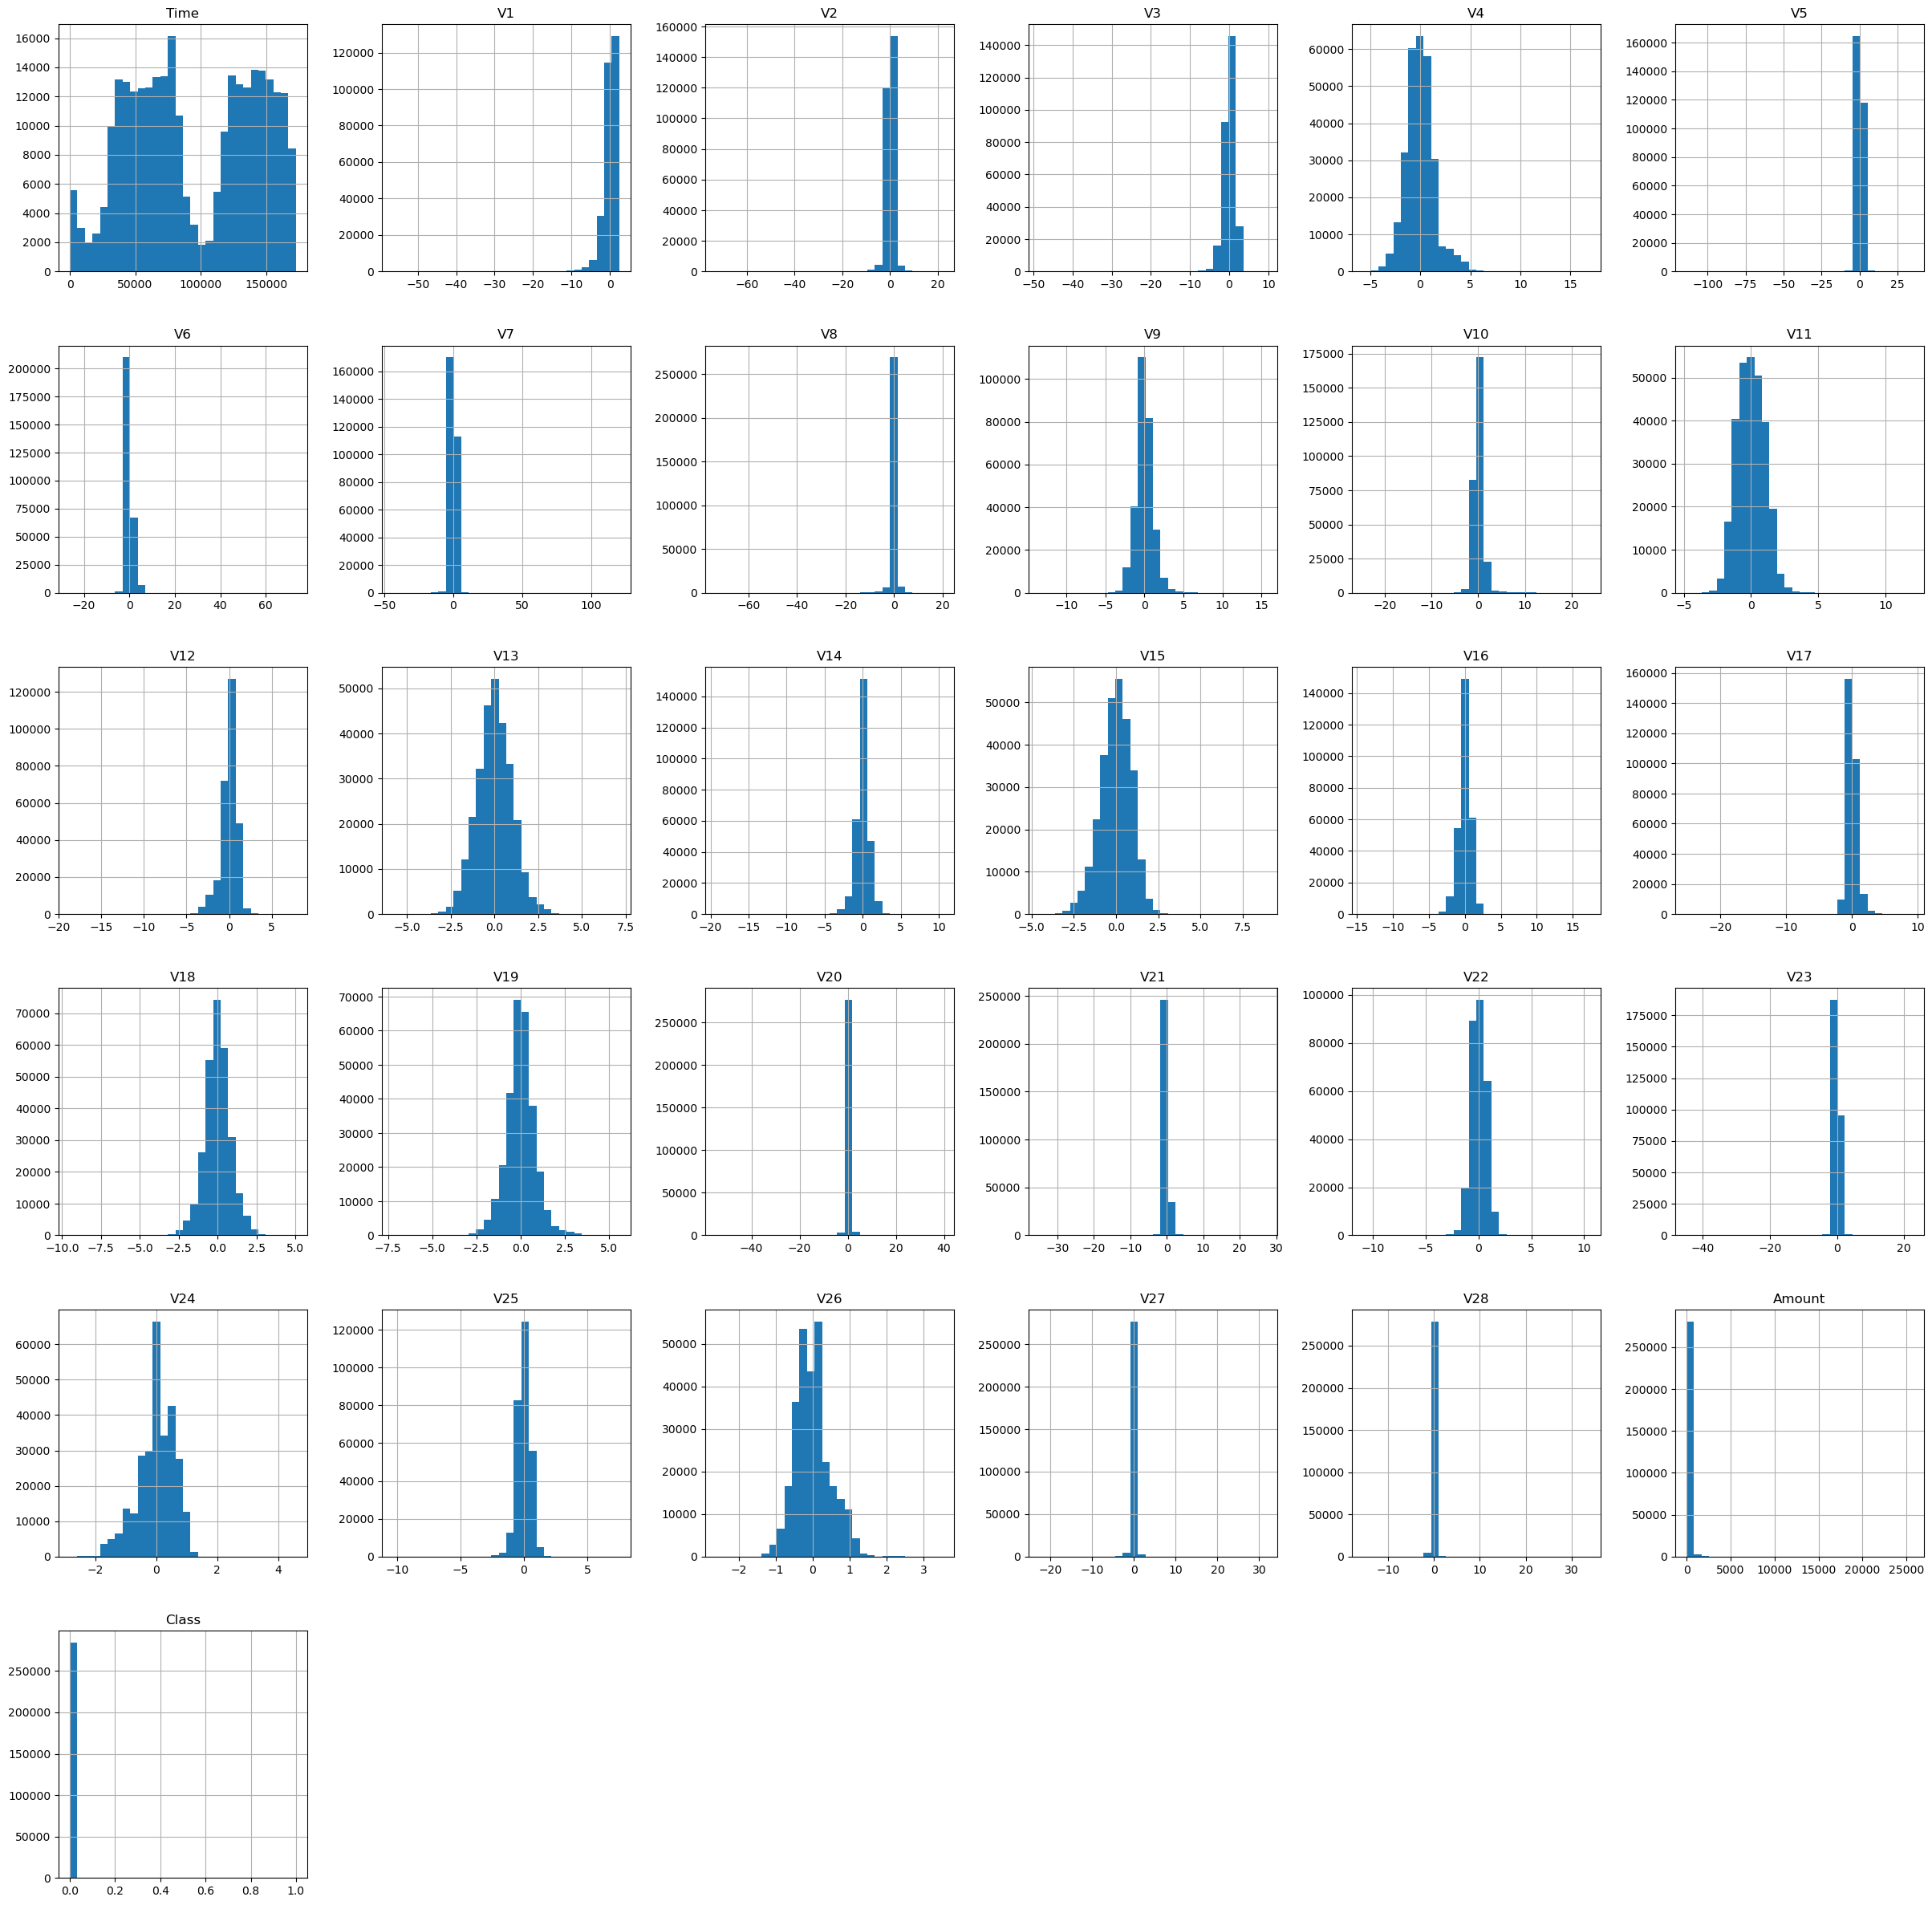

In [6]:
credit_data.hist(bins=30,figsize=(30,30))

* the class of credit card is that unbalanaced that we barely can see the fruad class 1 

<Axes: xlabel='Class', ylabel='Count'>

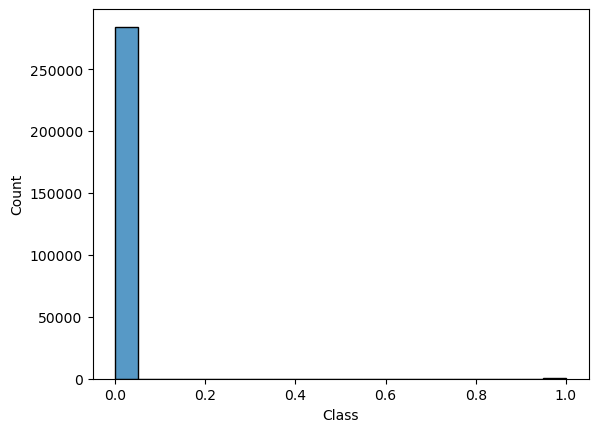

In [7]:
sns.histplot(credit_data['Class'])

* most amount of money or money that are exceed some amount of quantity 
* or max

In [8]:
# id 274771 is suspended because larg amount of money they have  
maxx= credit_data.query('Amount == 25691.16')
maxx
credit_risky= credit_data['Amount'].nlargest(10)
# but their class is not fruad so sometimes misunderstand can happens !
credit_data['Class'].iloc[credit_risky]

25691    0
19656    0
18910    0
12910    0
11898    0
11789    0
10199    0
10000    0
8790     0
8787     0
Name: Class, dtype: int64

* its already PCA format other wuse for the normal features of model logistics we defenitly needs to scale the data 

In [9]:
# disturbution of the logit transaction and fruad transaction 
# unusual unbalanced data
#fruad  =  credit_data[credit_data.class  == 1 ]
#not_fruad  = credit_data[credit_data.class == 0]
# this type of features eng make list format that command of pandas barely work with it and need to change it to another format 
# very unbalanced data
credit_data['Class'].value_counts()
fruad_num  = [x for x in credit_data['Class'] if x ]
print("len of fruad " ,len(fruad_num))
not_fruad_num = [x for x in credit_data['Class'] if not x ]
print("len of not fruad ",len(not_fruad_num))
balance = round(len(not_fruad_num) / len(fruad_num))
fruad_list  = [credit_data for x in credit_data['Class'] if x ]
not_fruad_list = [credit_data for x in credit_data['Class'] if not x ]

f'{balance} not fruad compare to fruad ' 

len of fruad  492
len of not fruad  284315


'578 not fruad compare to fruad '

In [10]:
# they are so basic sample of this projects because with SMOTE we can make this unbalanced data so better balanced
fruad  =  credit_data[credit_data.Class  == 1 ]
not_fruad  = credit_data[credit_data.Class == 0]
print(fruad.shape)
not_fruad.shape

(492, 31)


(284315, 31)

# stastical measurement

In [11]:
# mean percntile and  central measurment and also count and mean values 

print(fruad.Amount.describe())
not_fruad.Amount.describe()
# compare the value of each transaction 
compare = credit_data.groupby('Class').mean()
compare.insert(loc=0 , column='group',value=['not_fruad' ,'fruad'])
compare



count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


,group,Time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,not_fruad,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,fruad,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


# under sampling 

* we make the copy  of our sample with fruad and not fruad datas 

*  fruad umber is  -> 492

* almost not fruad was 500 more than fruad so the ratio was massed up the best solution is reshape the data and make the not fruad balance with fruad for better prediction

 
* for here we have many option but my goal is make feature which is save the attrebuite and save the ratio of our data not make the fruad and not fruad equal because its basically not probability of 50% to be fruad its usually less than 1% in real world our transaction will be fruad  

# note  :  these method basically are shows feature skills method that we can do but it does change real data nature and not good idea (make totally different dataset) !

In [12]:
samplee = credit_data[credit_data.Class == 1]
sample1 = credit_data[credit_data.Class == 0 ]
sample1_num = len(sample1) // 50
sample1= sample1.sample(n=sample1_num,random_state=21)
new_dataset_bad = pd.concat([sample1,samplee],axis=0)
# IF WE SEE we MADE data much more accurate and ratio rules is followed 
new_dataset_bad['Class'].value_counts()

Class
0    5686
1     492
Name: count, dtype: int64

array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <

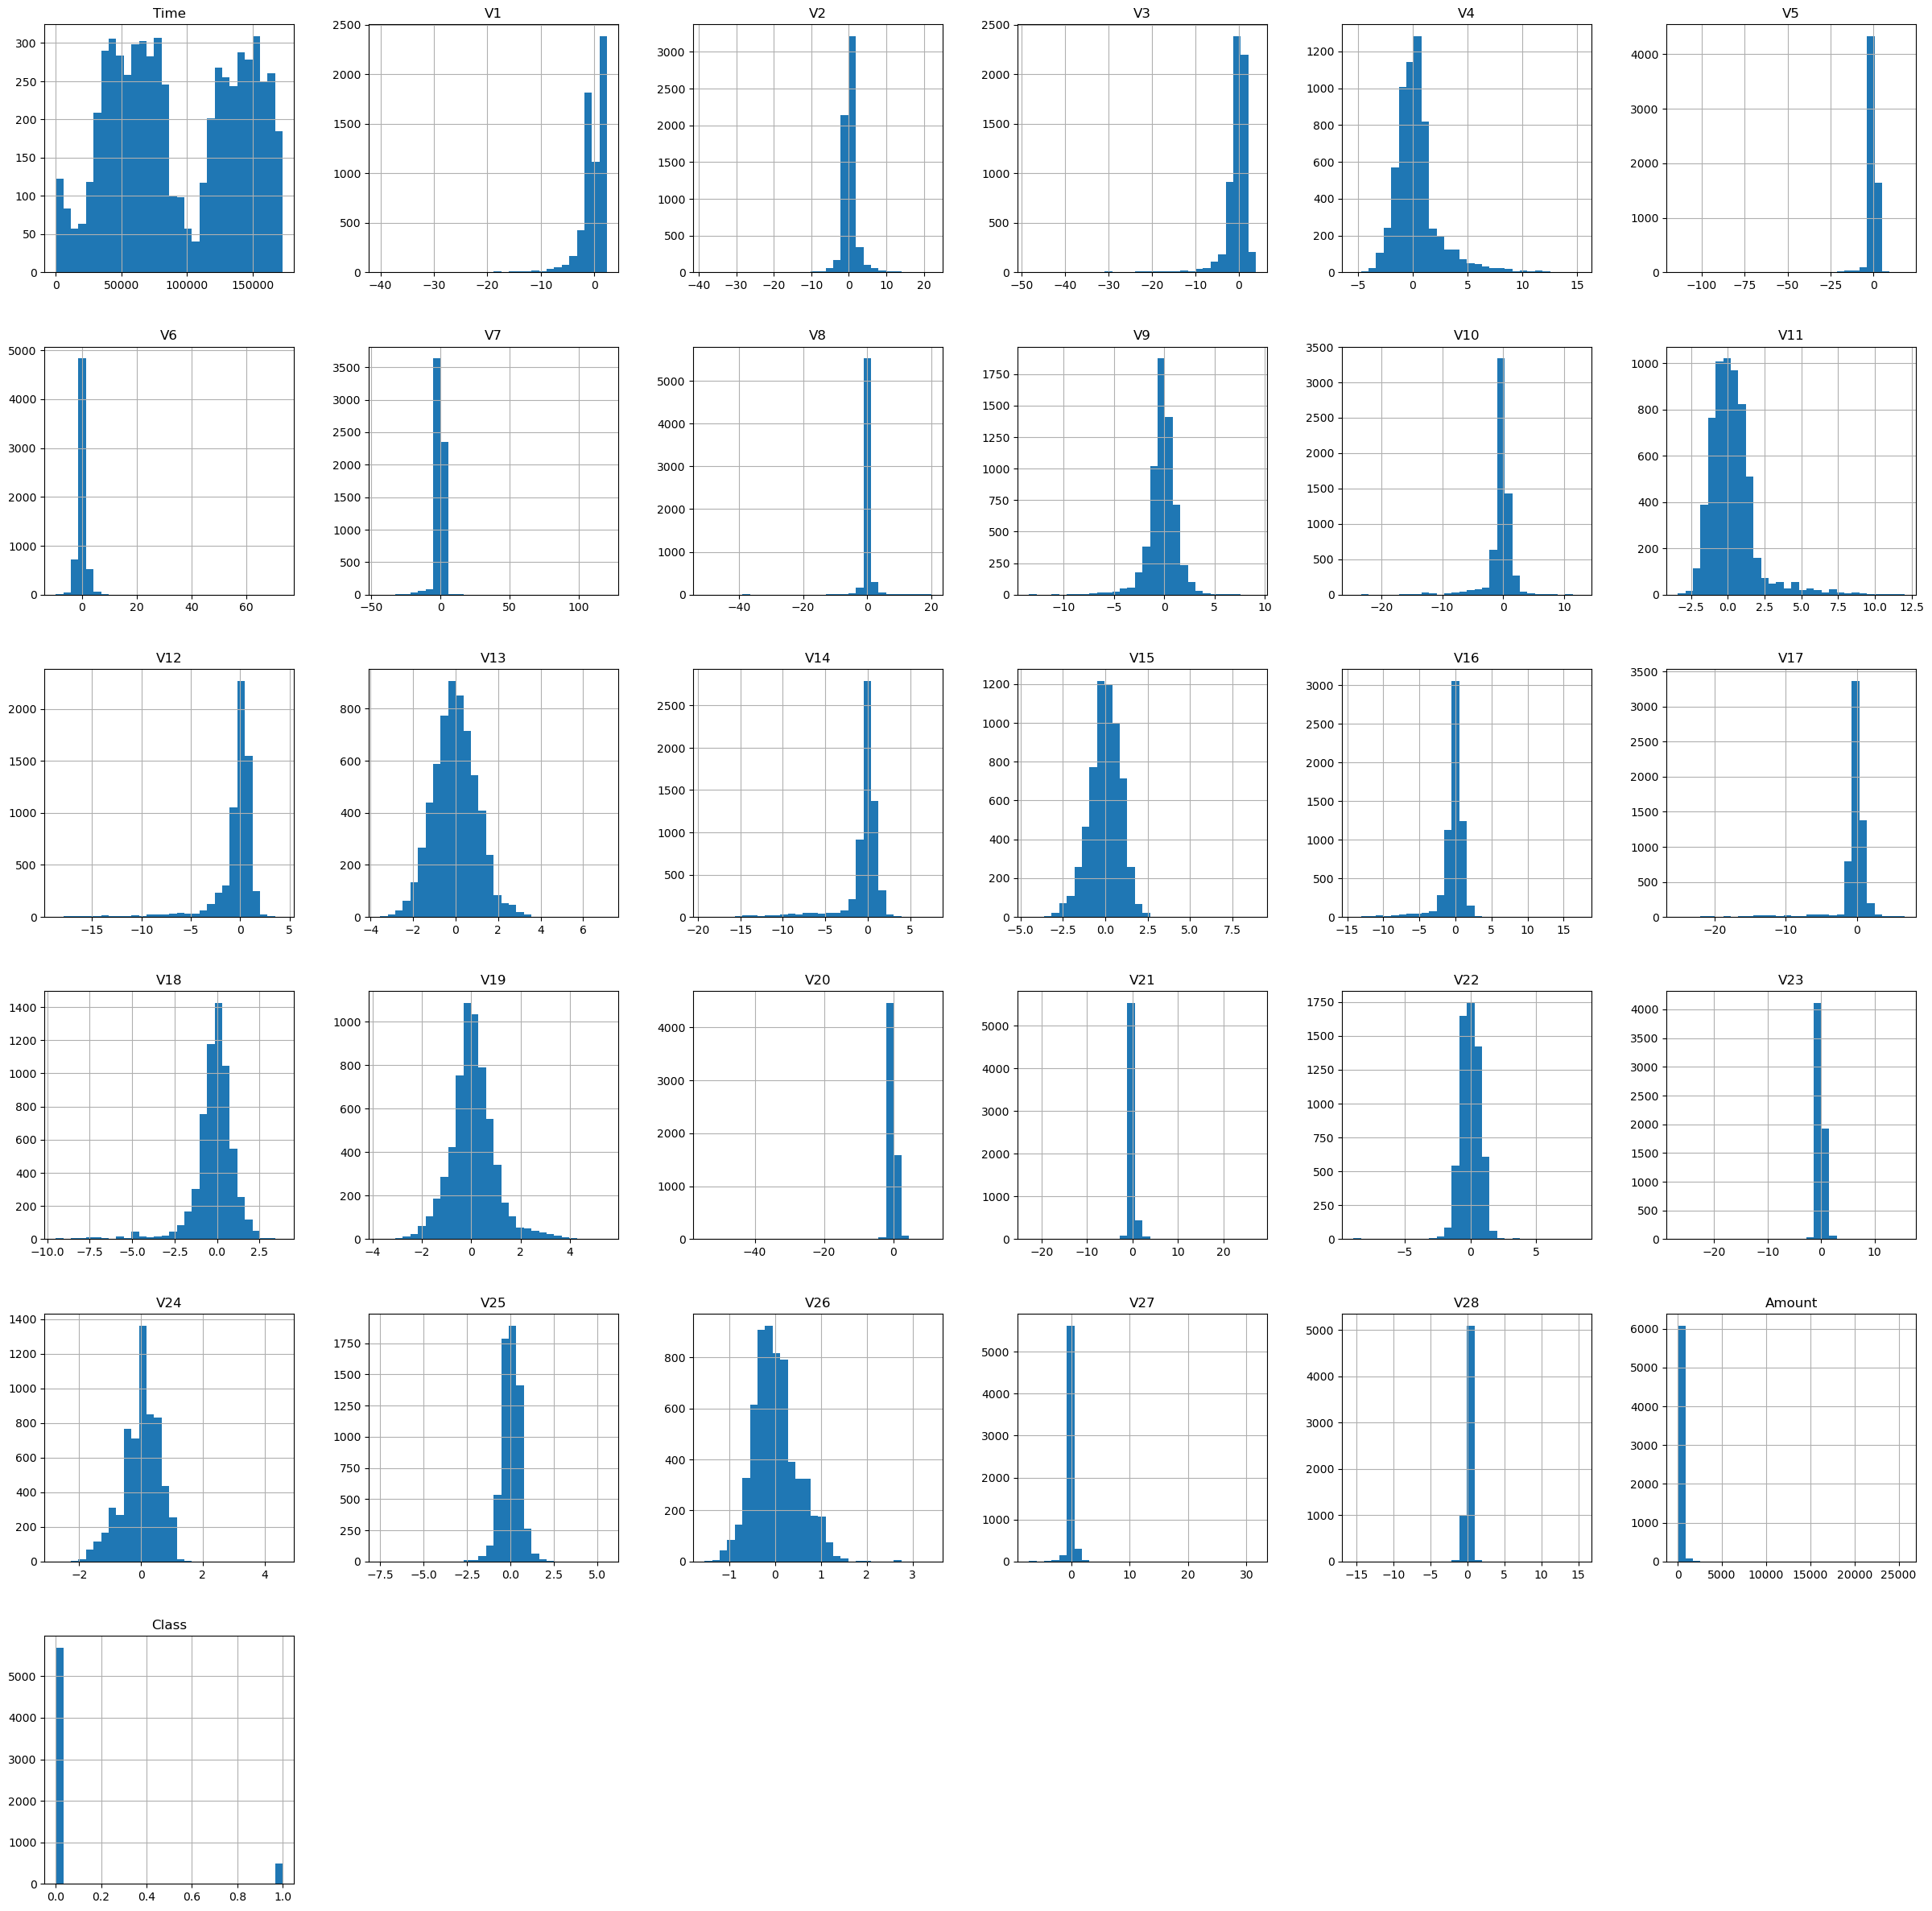

In [50]:
new_dataset_bad.hist(bins=30,figsize=(30,30))

* now the class 1 is clear that is exist due to the ratio change by changed the data 

<Axes: xlabel='Class', ylabel='Count'>

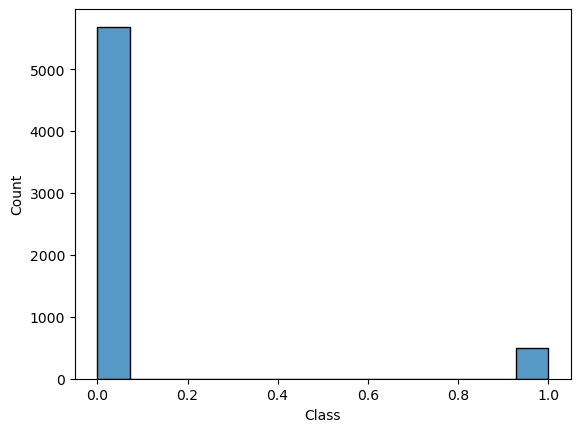

In [13]:
sns.histplot(new_dataset_bad['Class'])

* make size of data from real one to same as fruad ! big mistake !

In [14]:
sample_not_fruad = not_fruad.sample(n=492)
# now connect with the normal fruad ones 
new_dataset_bad_2 = pd.concat([sample_not_fruad,fruad],axis=0)
new_dataset_bad_2

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
274775,166201.0,-0.898085,0.753647,-0.407364,0.068195,2.295660,-0.785978,1.657798,-0.363186,-0.742937,...,0.064692,0.397887,-0.152407,0.577252,0.373053,-0.713722,-0.156449,-0.002953,30.55,0
106925,70194.0,1.220248,0.220729,0.005877,0.367760,0.185950,0.109251,-0.127787,0.141198,-0.143712,...,-0.257113,-0.750946,0.065289,-0.715942,0.196435,0.150317,-0.012864,0.009531,0.89,0
234078,147818.0,-0.898391,0.632526,1.065872,-0.718361,1.015920,-1.314766,0.980176,-0.213969,-0.433361,...,0.269319,0.663749,-0.586992,0.002799,1.074745,0.016618,-0.011690,0.048568,1.00,0
134184,80689.0,0.970885,-0.830703,0.871789,0.091514,-0.977597,0.604974,-0.789993,0.397034,1.113114,...,-0.132792,-0.380761,-0.011072,-0.245479,0.008058,0.968511,-0.045668,0.011182,100.07,0
143424,85345.0,1.339147,-0.745679,0.867743,-0.815060,-1.306270,-0.215388,-1.128362,0.105138,-0.627419,...,0.415783,1.100156,-0.161452,0.058012,0.436087,-0.047491,0.031378,0.013720,19.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


* now we have the equal shape data

In [15]:
new_dataset_bad_2.shape
sample_not_fruad.shape
# we randomize the data make some part of data and checked the mean of it with respect to class and it shows that the nature of our data is still same
# if it was bad sample it would be diffrenet mean and it showes vewry outliers was there 
new_dataset_bad_2.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,97177.693089,0.200271,0.074339,0.052338,0.042144,0.006774,-0.052249,0.047422,0.014061,0.068610,...,-0.013418,0.045024,0.008392,0.006928,0.024484,-0.014385,-0.043540,-0.005417,0.006683,76.316768
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <

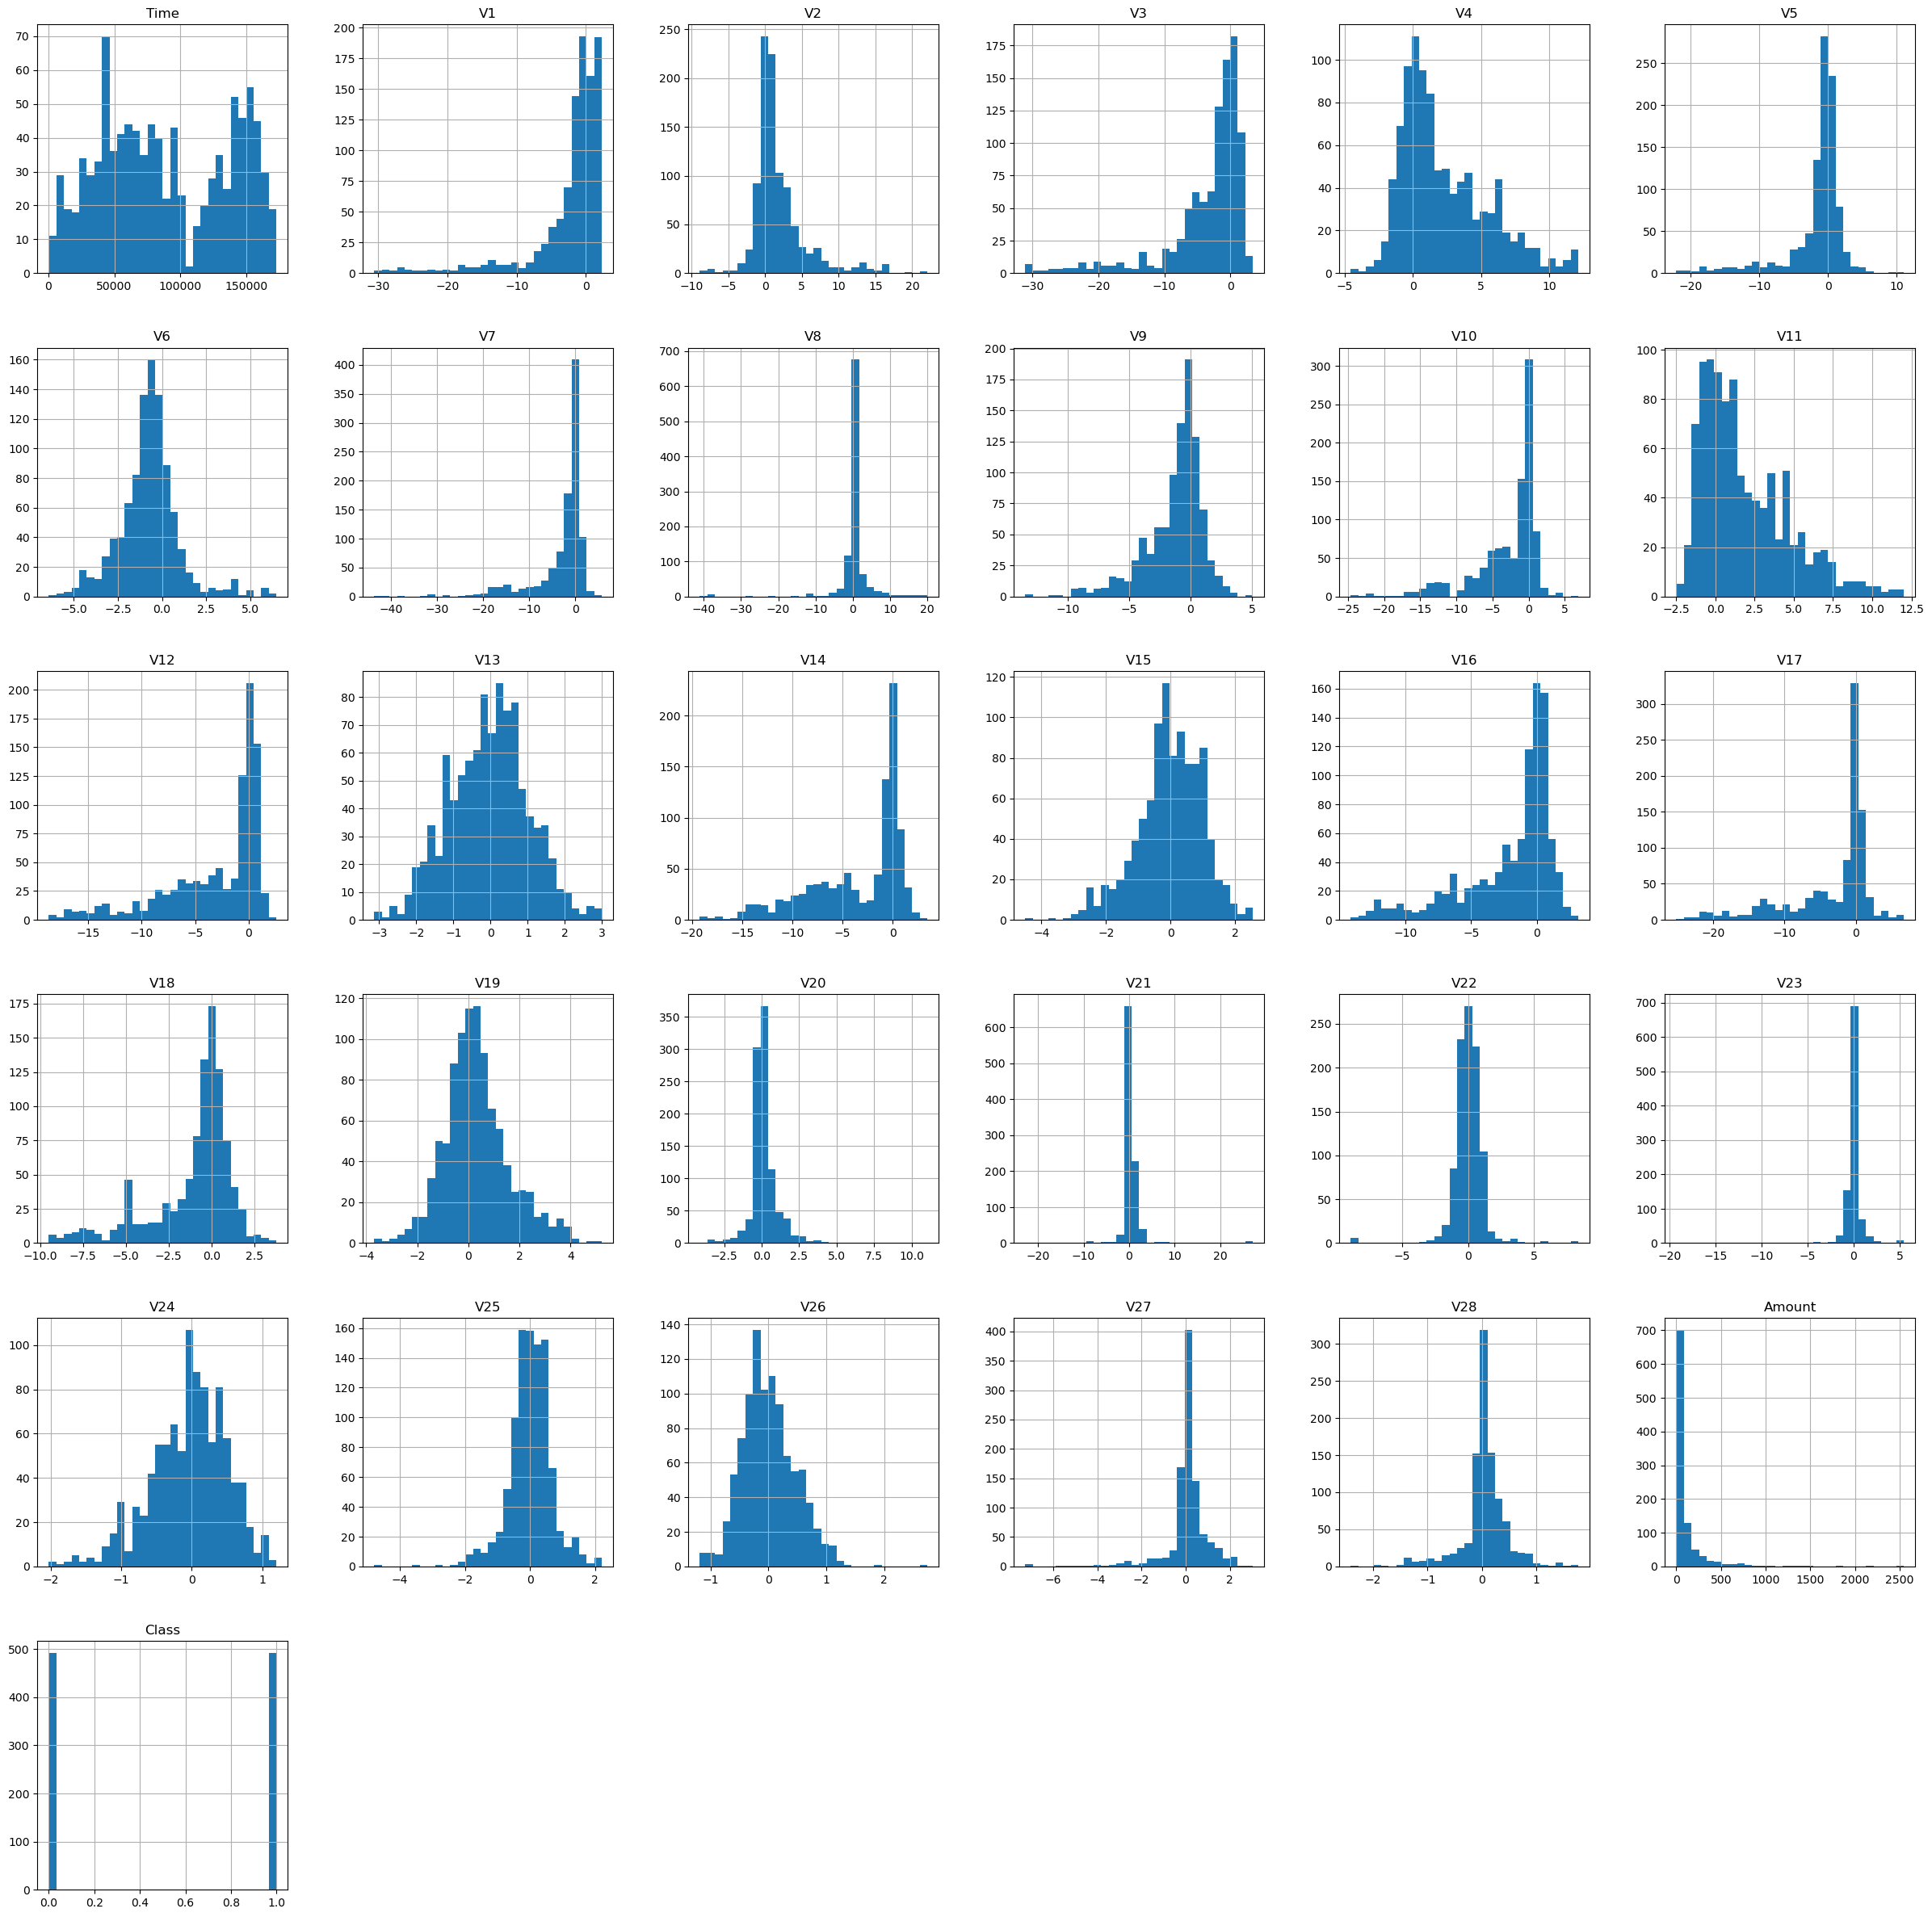

In [16]:
new_dataset_bad_2.hist(bins=30,figsize=(30,30))

when we equally seperate 0 and 1  ( kae it far from realstic data concepts of fruad


<Axes: xlabel='Class', ylabel='Count'>

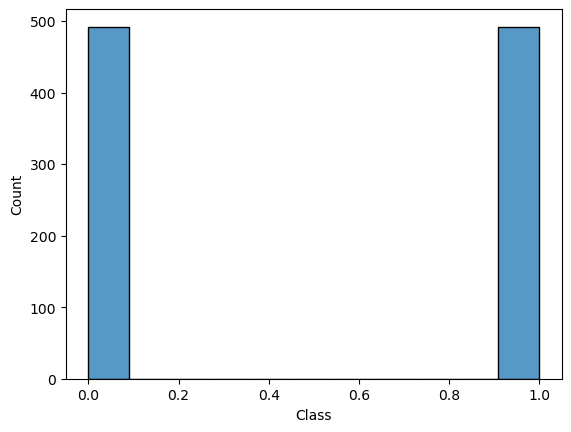

In [17]:
print(f'when we equally seperate 0 and 1  ( kae it far from realstic data concepts of fruad')
sns.histplot(new_dataset_bad_2['Class'])

# robust scaler 
* right one 

* all data doesnt need to be scale wont be touch to save the data features orginal and some of them needs to and we scale them 

* already all V columns are scaled so we can understand that only amount and time needs to be scale

array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <

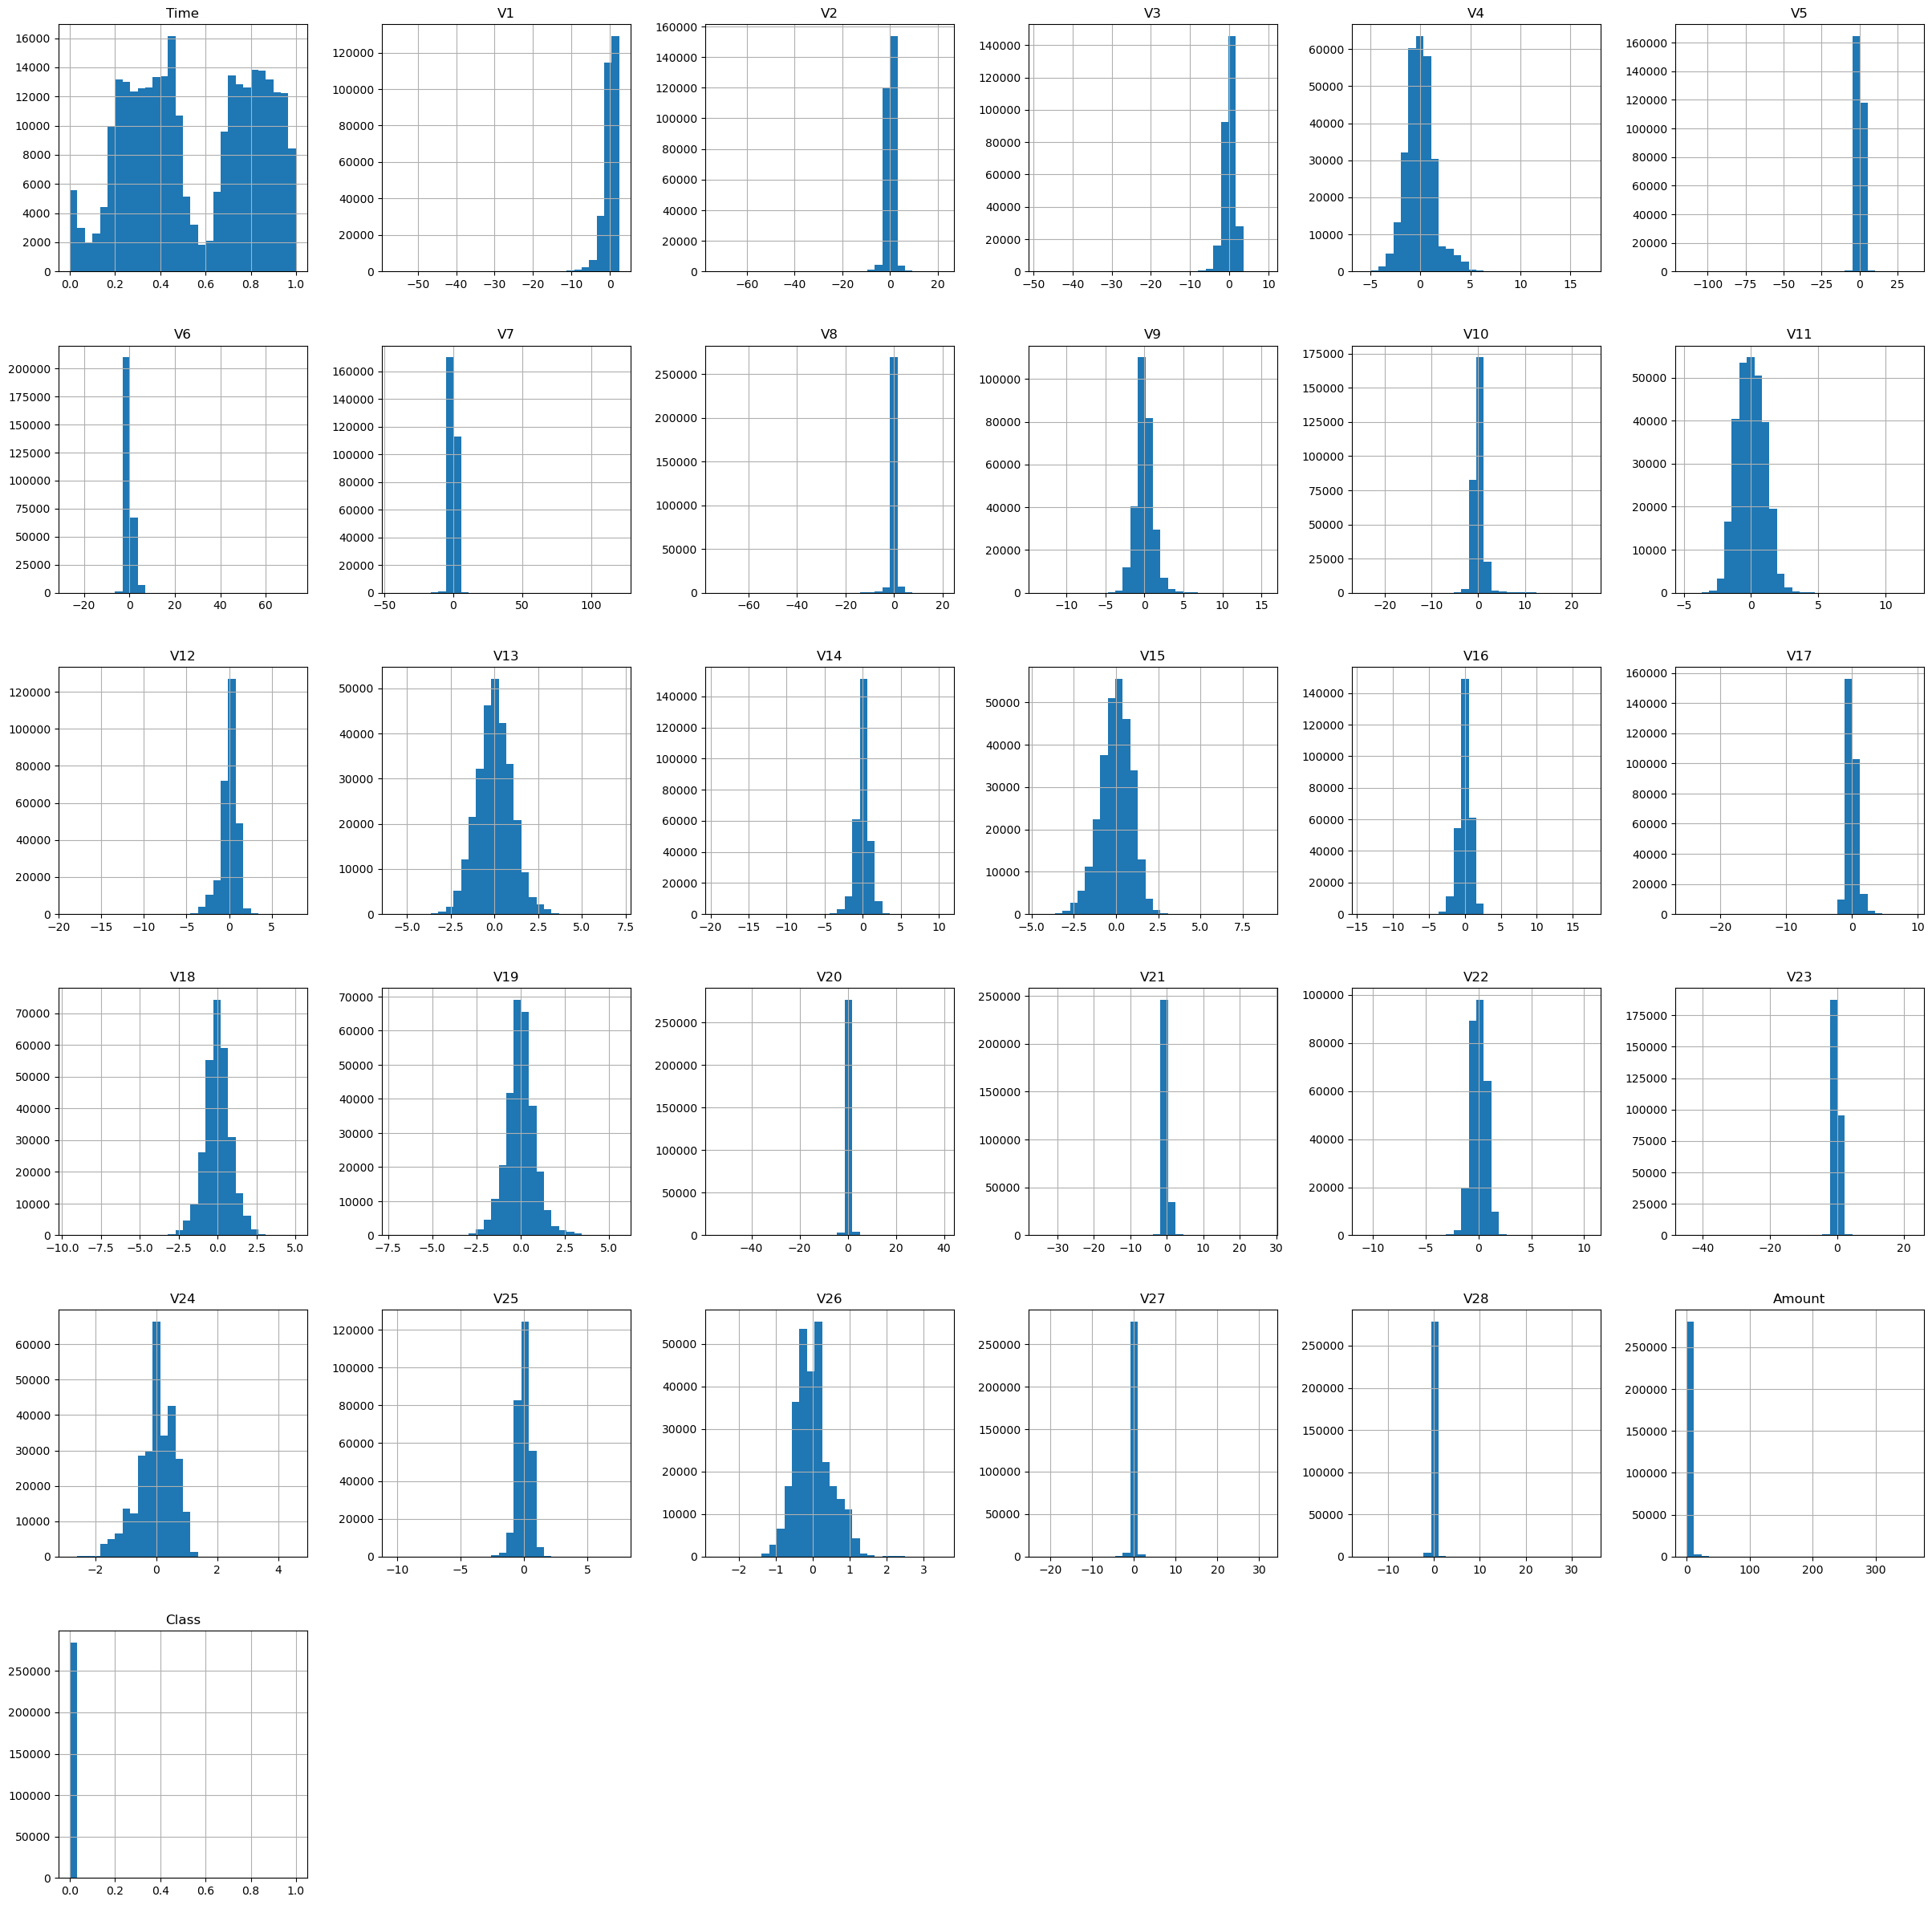

In [19]:
from sklearn.preprocessing import RobustScaler
new_datasets = credit_data.copy()
new_datasets['Amount'] = RobustScaler().fit_transform(new_datasets['Amount'].to_numpy().reshape(-1,1))
time  =  new_datasets['Time']
#scaled data time like a min max scaler 
new_datasets['Time'] = (time - time.min()) / (time.max() - time.min())
new_datasets.hist(bins=30 ,figsize=(30,30))

* shuffle data with randomstate to it save the shuffle for entire time we run it 

In [20]:
new_datasets = new_datasets.sample(frac=1,random_state=21)
new_datasets

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
47499,0.250203,-4.907464,-3.219507,1.976099,1.501927,0.089397,0.565583,-0.662498,-1.134323,3.474498,...,-0.657012,1.063759,-1.247375,0.293825,-0.890266,1.099830,-2.892506,0.858852,-0.224411,0
234614,0.856799,-2.343356,-0.956658,2.558260,2.960781,2.619159,-0.350503,-1.083410,0.613996,-1.031398,...,0.323283,0.187637,-0.028306,0.540639,0.673751,0.089682,-0.050855,0.112183,-0.307413,0
128968,0.456653,1.225044,0.135849,-0.232285,-0.062222,0.981707,1.707754,-0.353523,0.492103,-0.320422,...,-0.204101,-0.753336,0.302322,3.267346,0.216635,-0.042515,-0.036323,0.036737,-0.289387,0
182186,0.725138,-1.461526,0.519650,1.588467,-0.711261,0.042390,-0.343000,0.685782,-0.609369,1.327158,...,0.128365,0.903383,-0.231424,0.037264,-0.206913,0.505154,-0.880873,-0.177428,0.060924,0
180179,0.720033,-2.388231,-0.669561,2.824465,2.460076,3.215267,-0.105877,0.246819,-0.761898,-0.643063,...,-0.171976,0.428055,-0.959228,0.534217,0.524773,-0.117508,-0.919279,-0.473075,-0.296793,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63856,0.294545,-0.043734,-0.551311,1.569492,-1.903996,-1.151121,-0.053123,-0.499013,0.135010,-2.136722,...,-0.343545,-0.583264,-0.013246,-0.049053,-0.101647,-0.366528,0.056215,0.013936,0.111786,0
81968,0.342510,1.140277,-0.004898,0.072729,0.918752,-0.129861,-0.042564,-0.127994,0.223495,0.153317,...,0.066068,0.058538,-0.107472,-0.369613,0.528540,-0.288810,0.004279,0.001099,0.036331,0
140036,0.483252,-0.754934,-1.802975,0.866239,-1.690596,-3.007219,1.865597,0.741822,0.098395,-1.798257,...,0.243652,1.268334,0.620800,-0.282679,-1.342805,-0.245118,0.375048,0.193864,7.147349,0
202552,0.777715,2.051854,-1.051863,-2.279919,-1.689759,-0.048993,-0.868512,0.092609,-0.329633,-0.646595,...,-0.291720,-0.583088,0.081217,0.366751,-0.048046,0.634649,-0.124288,-0.065370,1.233005,0


In [21]:
df_train = new_datasets.drop('Class',axis=1)
df_test = new_datasets['Class']
df_train.dtypes
df_test

47499     0
234614    0
128968    0
182186    0
180179    0
         ..
63856     0
81968     0
140036    0
202552    0
80841     0
Name: Class, Length: 284807, dtype: int64

# train test valid spilit 

* another trick we could was because we shuffled it already we could solit from the size of our data 
 * n_sample.to_numpy  = 1000 
* train_size.to_numpy = 1000 *0.6 
* test_size.to_numpy = 1000 *0.2 
* valid_Size.to_numpy = 1000 *0.2
* dftrainb , dftest , dfvalid = [:train_size] , [train_size  valid_size ] , [train_size : valid_size + train_size] 

In [22]:
def train_valid_test_spilit(x: pd.DataFrame ,
                              y:pd.Series ,
                              startify : bool = True ,
                               valid_size:float=0.15,
                                test_size:float = 0.15,
                                    random_State: int = 21 ,
                                      shuffle : bool = True):
    n = len(x)
    if len(x) != len(y):
        raise ValueError(f'the size of the train and test arent match')
    if not random_State :
        raise ValueError(f'we did not choosed random_state address')
    
    rng  =  np.random.RandomState(random_State)
    indexx = np.arange(n)
    choose = rng.permutation(indexx) if shuffle   else indexx
    
    n_val = int(np.ceil(n * float(valid_size)))
    n_test = int(np.ceil(n * float(test_size)))
    n_test = min(n-1,n_test)
    n_train = n - n_val - n_test
    print(n_val)
    print(n_train)
    index_train  = choose[n_test:]
    index_valid = choose[n_train: n_train + n_val]
    index_test =  choose[:n_test]
    if isinstance(x,pd.DataFrame):
     trainx , trainy =  x.iloc[index_train] , y.iloc[index_train]
     valdx , valdy =  x.iloc[index_valid] , y.iloc[index_valid]
     testx , testy = x.iloc[index_test] ,y.iloc[index_test]
    else:
       trainx, testx = x[index_train], x[index_test]
       trainy,testy  = y[index_train], y[index_test]
    if startify :
     x = trainy.mean()
     b = valdy.mean()
     c = testy.mean()  
     x = b 
     b = c
     c = x 
    return trainx , valdx ,testx, trainy  , valdy  , testy 

    

In [23]:
xtrain , xtest , ytrain , ytest = train_test_split(df_train,df_test,test_size=0.15,random_state=21 ,stratify=df_test, shuffle=True)
len(xtest)

42722

In [24]:
myxtrainn , myxvall , myxtestt , myytrainn , myyvall,  myytestt = train_valid_test_spilit(df_train,df_test,True,0.15,0.15,random_State=21,shuffle=True)

[myytestt.value_counts(),myytrainn.value_counts(),myyvall.value_counts()]

42722
199363


[Class
 0    42654
 1       68
 Name: count, dtype: int64,
 Class
 0    241661
 1       424
 Name: count, dtype: int64,
 Class
 0    42657
 1       65
 Name: count, dtype: int64]

# SMOTE 
* usually for the unbalanced data scale them for train models better than standard scale and manual one consider that PCA 

In [25]:
from imblearn.over_sampling import SMOTE
myxtrainn , myxvall , myxtestt , myytrainn , myyvall,  myytestt = train_valid_test_spilit(df_train,df_test,True, valid_size=0.15 , test_size=0.15,random_State=21,shuffle=True)

# apply the smote for the hanlde the imbalance data 
smote = SMOTE(random_state=21)
stdd = StandardScaler()
my_xtrain_sampx = stdd.fit_transform(myxtrainn)
my_ytrain_sampx = stdd.transform(myxvall)
my_xtrain_samp ,my_ytrain_samp = smote.fit_resample(myxtrainn,myytrainn)
# by SMote method we startifed the whole datasets
pd.DataFrame(my_xtrain_samp,my_ytrain_samp).groupby('Class').mean()

42722
199363


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,0.775152,0.479693,-2.823349,-1.619367,0.715178,-0.780117,0.589333,0.518436,-0.053246,0.844512,...,1.457542,0.258495,-0.962211,-0.360642,0.087324,-0.642866,-0.762461,-0.125982,0.096741,10.801789
1,0.208835,-1.543678,1.421673,0.690860,-0.749632,-0.541012,-0.239964,-0.192433,1.142846,-0.287727,...,-0.151703,-0.069951,-0.260434,0.063410,0.021595,-0.246004,0.317311,0.166324,0.098848,-0.251520


* note :  based on problem based that we care to just find fruad or we wanted we have balance of take both our diffrenet score tell us

smote trained log -> recall : high percision : low  ------> it showed we labled many unfruad as fruad and because we so much guess recall is high and not precision is low

normal trained log  -> f1 score is quite good ---> showes that we have ballance although we lost some fruad but we made in general not bad 

In [26]:
# for validation after smote scaled 
logic = LogisticRegression(random_state=21,class_weight= {0 : 1 , 1: 10})
logic.fit(my_xtrain_samp,my_ytrain_samp)
print({'smote_score' : logic.score(my_xtrain_samp,my_ytrain_samp)})
print(classification_report(myyvall,logic.predict(myxvall)))
logic.fit(myxtrainn,myytrainn)
print({'without_smote' :logic.score(myxtrainn,myytrainn)})
print(classification_report(myyvall,logic.predict(myxvall)))


{'smote_score': 0.9056322699980551}
              precision    recall  f1-score   support

           0       1.00      0.83      0.91     42657
           1       0.01      0.97      0.02        65

    accuracy                           0.83     42722
   macro avg       0.50      0.90      0.46     42722
weighted avg       1.00      0.83      0.90     42722

{'without_smote': 0.9992771134105789}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42657
           1       0.79      0.80      0.79        65

    accuracy                           1.00     42722
   macro avg       0.89      0.90      0.90     42722
weighted avg       1.00      1.00      1.00     42722



* function evaluation for understand we did what in our report well enough

In [27]:
def compare(model , x:pd.DataFrame , y:pd.Series , model_name ):
    # we first evaulate the validation part  part 
    y_pred_val = model.predict(myxvall)
    y_pred_prob = model.predict_proba(myxvall)[:,1]
    y_pred_train = model.predict(myxtrainn)

    print(model_name)
    roc = roc_auc_score(y_pred_val,myyvall)
    print(confusion_matrix(y_pred_val,myyvall))

    rocc = roc_auc_score(y_pred_val,myyvall)
    f11 = f1_score(y_pred_val,myyvall)
    pr = precision_score(y_pred_val,myyvall)
    reccc = recall_score(y_pred_val,myyvall)
    valid_logic = pd.DataFrame([rocc,f11,pr,reccc]).transpose().rename({0 : 'roc_auc' , 1 : 'f1_score ',2 : 'perecision_score', 3 : 'recall_score'},axis=1)
    
# in here we go fro train part

    
    print(model_name)
    print(confusion_matrix(y_pred_train,myytrainn))

    rocc_t = roc_auc_score(y_pred_train,myytrainn)
    f11_t = f1_score(y_pred_train,myytrainn)
    pr_t = precision_score(y_pred_train,myytrainn)
    reccc_t = recall_score(y_pred_train,myytrainn)
    train_logic_t = pd.DataFrame([rocc_t,f11_t,pr_t,reccc_t]).transpose().rename({0 : 'roc_auc' , 1 : 'f1_score ',2 : 'perecision_score', 3 : 'recall_score'},axis=1)
    

    return y_pred_train ,y_pred_val , y_pred_prob , valid_logic ,train_logic_t


In [28]:
y_pred_train,y_Pred_val , y_pred_prob  , val_logic , train_logic = compare(logic,x=df_train,y=df_test,model_name="logistic_regression")
train_logic

logistic_regression
[[42643    13]
 [   14    52]]
logistic_regression
[[241564     78]
 [    97    346]]


,roc_auc,f1_score,perecision_score,recall_score
0,0.890358,0.798155,0.816038,0.781038


In [29]:
val_logic

,roc_auc,f1_score,perecision_score,recall_score
0,0.893787,0.793893,0.8,0.787879


# svm model 

* note :  based on problem based that we care to just find fruad or we wanted we have balance of take both our diffrenet score tell us

smote trained svm -> recall : high percision : low  ------> it showed we labled many unfruad as fruad and because we so much guess recall is high and not precision is low

normal trained svm  -> f1 score is quite good ---> showes that we have ballance although we lost some fruad but we made in general not bad 

In [150]:
from sklearn.svm import LinearSVC
svm = LinearSVC('l1',random_state=21)
svm.fit(my_xtrain_samp,my_ytrain_samp)
print(svm.score(my_xtrain_samp,my_ytrain_samp))
predict = svm.predict(myxvall)
print(classification_report(predict,myyvall))


svm.fit(myxtrainn,myytrainn)
predict = svm.predict(myxvall)
print(svm.score(myxtrainn,myytrainn))
print(classification_report(predict,myyvall))

0.9402841170068815
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     41863
           1       0.89      0.07      0.13       859

    accuracy                           0.98     42722
   macro avg       0.94      0.53      0.56     42722
weighted avg       0.98      0.98      0.97     42722

0.9991366668732057
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42683
           1       0.54      0.90      0.67        39

    accuracy                           1.00     42722
   macro avg       0.77      0.95      0.84     42722
weighted avg       1.00      1.00      1.00     42722



# cross-validation method k-fold startify

* for the grid search we need to cut our data other wise it takes alot of time

In [63]:
grid_search = new_datasets.sample(n=len(new_datasets)//100 , random_state=21)
df_trainn = grid_search.drop('Class',axis=1)
df_testt = grid_search['Class']

* remake the spilit again but with smaller data due to overfitting cost function and big O  notation time consuming of trees alghorthims

In [65]:
myxtrainn_f , myxvall_f , myxtestt_f , myytrainn_f , myyvall_f,  myytestt_f = train_valid_test_spilit(df_trainn,df_testt,True,0.15,0.15,random_State=21,shuffle=True)


428
1992


* due to unbalanced data and we want use the trees models first scaling for them is not naccessrly but find best parameter is big deal so we use cross validation to find best hyperparameters 

* params and it hyperparameters ranges 

In [94]:
cvv = StratifiedKFold(n_splits=5, shuffle=True , random_state=21)
cvkfold = KFold(n_splits=5 , shuffle=True , random_state=21)
tree_paramss = { 
    'max_depth' : [ 3, 5 , 7 ,10 ,15],
    'min_samples_split' : [2 ,5 ,10 ],
    'min_samples_leaf' : [1, 5 , 10] , 
    'max_features' : ['sqrt', 'log2'],
    'class_weight' : ['balanced']
}
forest_params = {
    'n_estimators' : [100,150,200],
    'max_depth' : [ 5, 10 ,15],
    'min_samples_split' : [2 ,5 ,10 ],
    'min_samples_leaf' : [1, 2 , 5] , 
    'max_features' : ['log2'],
    'class_weight' : ['balanced']
}


scoring = {
    'percision' : 'percision' ,
    'recall' : 'recall' , 
    'f1' : 'f1' , 
    'roc_auc' : 'roc_auc'
 }



 # decision tree 
 * with grid search due to find best params in balanced format model 

In [66]:
dt  = DecisionTreeClassifier(random_state=21)
dt_grid_kfold = GridSearchCV(estimator=dt , param_grid=tree_paramss , cv= cvkfold , scoring='f1' , n_jobs=-1 , verbose=2 , return_train_score=True, error_score='raise')
dt_grid = GridSearchCV(estimator=dt , param_grid=tree_paramss , cv=cvv , scoring='f1' , n_jobs=-1 , verbose=2 , return_train_score=True, error_score='raise')
dt_grid.fit(myxtrainn_f,myytrainn_f)
dt_grid_kfold.fit(myxtrainn_f,myytrainn_f)


descision_tree_result = [dt_grid_kfold.best_params_
,dt_grid_kfold.best_score_
,dt_grid.best_params_
,dt_grid.best_score_]

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Fitting 5 folds for each of 90 candidates, totalling 450 fits


In [67]:
descision_tree_result
dt_predict_train = dt_grid.predict(myxtrainn)
dt_predict = dt_grid.predict(myxvall)
print(classification_report(dt_predict_train,myytrainn))
print(classification_report(dt_predict,myyvall))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    241214
           1       0.58      0.28      0.38       871

    accuracy                           1.00    242085
   macro avg       0.79      0.64      0.69    242085
weighted avg       1.00      1.00      1.00    242085

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42580
           1       0.60      0.27      0.38       142

    accuracy                           1.00     42722
   macro avg       0.80      0.64      0.69     42722
weighted avg       1.00      1.00      1.00     42722



# randomforest 
* with grid search to goal to find best param with startifed folder k balance 

In [68]:
# for enasmblers and tree format data we doesnt need to use scales data in most times but in here because we want play even role we used it

rf = RandomForestClassifier(random_state=21)
rf_grid=GridSearchCV(estimator=rf ,param_grid=forest_params , cv =cvv ,scoring='f1', n_jobs=-1,verbose=1,return_train_score=True)
rf_grid.fit(myxtrainn_f,myytrainn_f)


random_forest_result = [
rf_grid.best_params_,
rf_grid.best_score_]
random_forest_result

Fitting 5 folds for each of 81 candidates, totalling 405 fits


[{'class_weight': 'balanced',
  'max_depth': 5,
  'max_features': 'log2',
  'min_samples_leaf': 1,
  'min_samples_split': 10,
  'n_estimators': 100},
 np.float64(0.5333333333333333)]

In [69]:
rf_predict_train = rf_grid.predict(myxtrainn_f)
rf_predict = rf_grid.predict(myxvall_f)
print(classification_report(rf_predict_train,myytrainn_f))
print(classification_report(rf_predict,myyvall_f))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2414
           1       1.00      1.00      1.00         6

    accuracy                           1.00      2420
   macro avg       1.00      1.00      1.00      2420
weighted avg       1.00      1.00      1.00      2420

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       427
           1       1.00      1.00      1.00         1

    accuracy                           1.00       428
   macro avg       1.00      1.00      1.00       428
weighted avg       1.00      1.00      1.00       428



* function evaluation one by one to we see how report goes exaclty

In [70]:
def best_model(model , xtest, ytest ,model_name):
    y_pred = model.predict(xtest)
    y_pred_prob = model.predict_proba(xtest)[:,1]
    
    print(model_name)
    roc = roc_auc_score(ytest,y_pred)
    print(roc)
    print(confusion_matrix(ytest,y_pred))
    
    rocc = roc_auc_score(ytest,y_pred)
    f11 = f1_score(y_pred,ytest)
    pr = precision_score(y_pred,ytest)
    reccc = recall_score(y_pred,ytest)
    tree_val = pd.DataFrame([rocc,f11,pr,reccc]).transpose().rename({0 : 'roc_auc' , 1 : 'f1_score ',2 : 'perecision_score', 3 : 'recall_score'},axis=1)
    return y_pred , y_pred_prob , tree_val 

dt_best = dt_grid.best_estimator_
rf_best = rf_grid.best_estimator_
rt_gred , rt_proba , treeval  = best_model(dt_best, myxtestt , myytestt,'Decision tree')
rf_gred , rf_proba , forestval  = best_model(rf_best,xtest,ytest , 'random forest')
treeval , forestval

Decision tree
0.7999584205605157
[[42525   129]
 [   27    41]]
random forest
0.7769566837518441
[[42642     6]
 [   33    41]]


(    roc_auc  f1_score   perecision_score  recall_score
 0  0.799958   0.344538          0.602941      0.241176,
     roc_auc  f1_score   perecision_score  recall_score
 0  0.776957   0.677686          0.554054       0.87234)

In [71]:
columns=[val_logic,train_logic,treeval,forestval]
columns

[    roc_auc  f1_score   perecision_score  recall_score
 0  0.893787   0.793893               0.8      0.787879,
     roc_auc  f1_score   perecision_score  recall_score
 0  0.890358   0.798155          0.816038      0.781038,
     roc_auc  f1_score   perecision_score  recall_score
 0  0.799958   0.344538          0.602941      0.241176,
     roc_auc  f1_score   perecision_score  recall_score
 0  0.776957   0.677686          0.554054       0.87234]

# random forest isolate 
* its our perpuse to put out the anomoly data (fruad)random forest isolation thanks to tree based give penality to the tree to the roots of one side  of it finish faster it helps speed and acuuracy on our model

In [96]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, make_scorer, f1_score
import numpy as np

isolation_forest_params = {
    'n_estimators': [100, 150, 200],
    'contamination': [0.05, 0.1],
    'max_samples': ['auto', 0.7],
    'max_features': [1.0, 0.7],
    'random_state': [21]
}

def iso_f1_scorer(y_true, y_pred):
    y_pred_binary = (y_pred == -1).astype(int)
    return f1_score(y_true, y_pred_binary)

rf_isolate = IsolationForest(random_state=21)

rf_isolate_grid = GridSearchCV(
    estimator=rf_isolate, 
    param_grid=isolation_forest_params, 
    scoring=make_scorer(iso_f1_scorer),
    cv=cvv, 
    n_jobs=1, 
    verbose=1, 
    return_train_score=True
)

rf_isolate_grid.fit(myxtrainn_f, myytrainn_f)

y_pred = rf_isolate_grid.predict(myxvall)
y_pred_binary = (y_pred == -1).astype(int)
print(classification_report(myyvall, y_pred_binary))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
              precision    recall  f1-score   support

           0       1.00      0.95      0.98     42657
           1       0.03      0.91      0.06        65

    accuracy                           0.95     42722
   macro avg       0.51      0.93      0.52     42722
weighted avg       1.00      0.95      0.97     42722



* based on recall its great really by it bother in precision

# gredient boosting 

In [107]:
gred = GradientBoostingClassifier(n_estimators = 500 , learning_rate = 0.6 , random_state =  21)
gred.fit(myxtrainn_f,myytrainn_f)
gred.score(myxtrainn_f,myytrainn_f)
print(classification_report(myyvall,gred.predict(myxvall)))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42657
           1       0.44      0.54      0.49        65

    accuracy                           1.00     42722
   macro avg       0.72      0.77      0.74     42722
weighted avg       1.00      1.00      1.00     42722



# catboost 
* simple set up for better f1 

In [113]:
model = CatBoostClassifier(
    # number of boosting  (trees)
    iterations =  500, 
    #how ever deeper its gonna be more complex carefull of overfitting 
    depth  = 6 ,
    # learning rate size of tree in range of 0.00 to 1.00
    learning_rate  = 0.06 ,
    # important features that we find with shap 
    # overfitting prevention
    min_data_in_leaf = 20 , 
    random_strength = 1.0 ,
    # based on rarely we have fruad we give 0 weight 1 and for 1 to 10 high weights 
    class_weights = [1,10] ,   
    early_stopping_rounds = 50 ,
    verbose = 100 ,
    eval_metric = 'AUC',
    thread_count = -1 ,
    random_seed = 21 ,


)


* evaluation metrics of our catboost model

In [112]:
model.fit(my_xtrain_samp,my_ytrain_samp)
y_pred = model.predict(myxvall)
y_pred1 = model.predict(myxtrainn)
# for validation part
rocc = roc_auc_score(myyvall,y_pred)
f11 = f1_score(y_pred,myyvall)
pr = precision_score(y_pred,myyvall)
reccc = recall_score(y_pred,myyvall)
# for test part 
rocc = roc_auc_score(myytrainn,y_pred1)
f11 = f1_score(y_pred1,myytrainn)
pr = precision_score(y_pred1,myytrainn)
reccc = recall_score(y_pred1,myytrainn)
tree_val = pd.DataFrame([rocc,f11,pr,reccc]).transpose().rename({0 : 'roc_auc' , 1 : 'f1_score ',2 : 'perecision_score', 3 : 'recall_score'},axis=1)
tree_val 

0:	total: 64.1ms	remaining: 5m 20s


KeyboardInterrupt: 

# feature selection and method to check our v 

<Axes: >

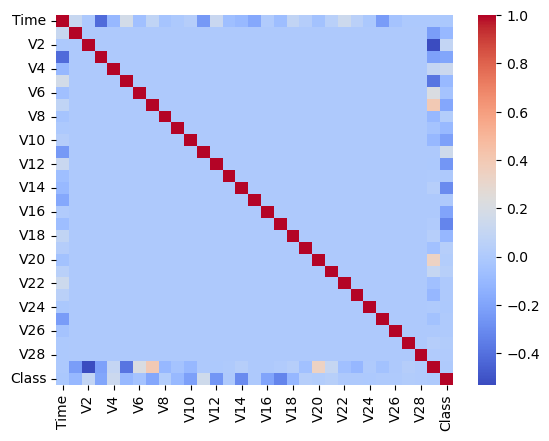

In [115]:
# as here we told PCA abalysis made our data mostly independent from each other 
corrleations = credit_data.corr()
sns.heatmap(corrleations,cmap='coolwarm')

In [ ]:
model =  RandomForestClassifier(n_estimators=100 , random_state=21)
model.fit(myxtrainn,myytrainn)
important = model.feature_importances_
imprtant_features =pd.DataFrame(important)

imprtant_features.transpose()

* shape here tells us direct effect of the V features on our target the red is high  and the blue is low and the right and left show these high and low effect 
* its based on game theory to any indivusal feature try to play yheir own role and some relate to the target

! before Smote 

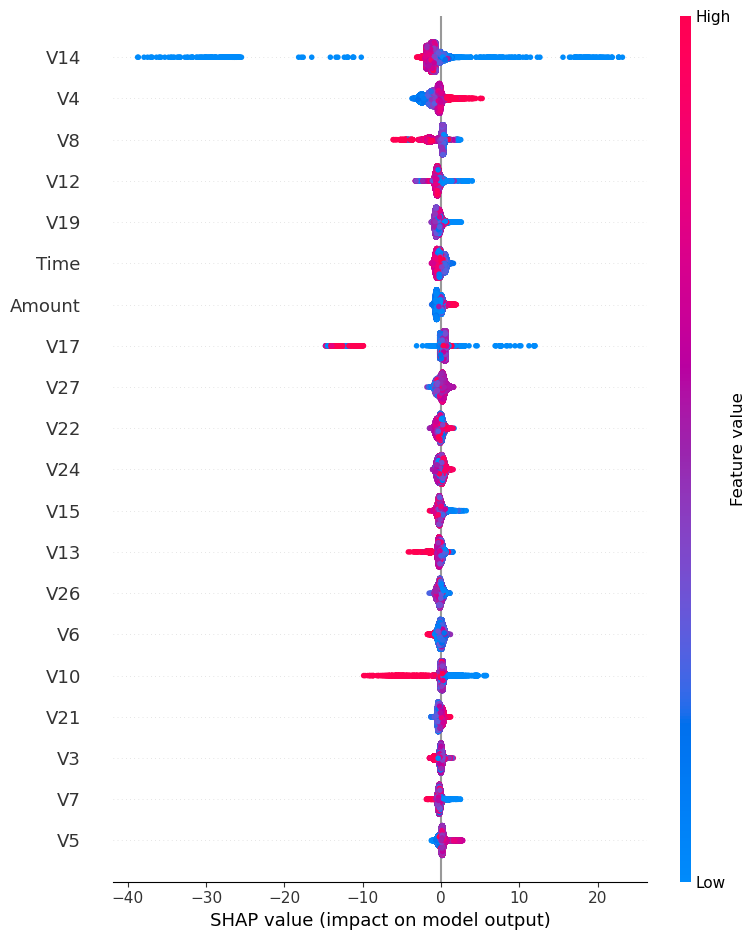

In [34]:
import shap
model = xgb.XGBClassifier().fit(myxtrainn,myytrainn)
explainer  = shap.TreeExplainer(model)
shap_val = explainer.shap_values(myxtestt)
shap.summary_plot(shap_val,myxtestt)


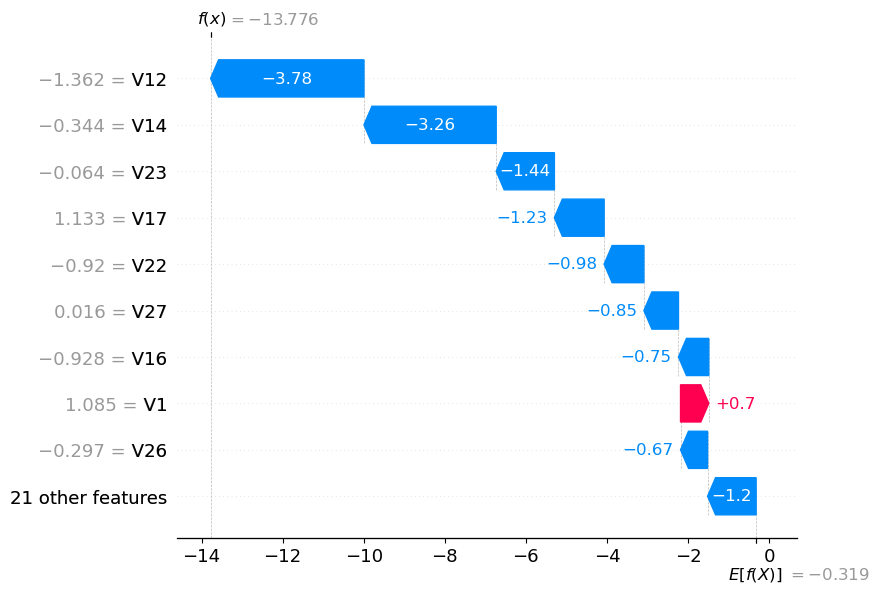

In [54]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_val[0],  # SHAP values for first prediction
        base_values=explainer.expected_value,  # Expected value
        data=myxtestt.iloc[0],  # Feature values for first prediction
        feature_names=myxtestt.columns.tolist(),
    ))

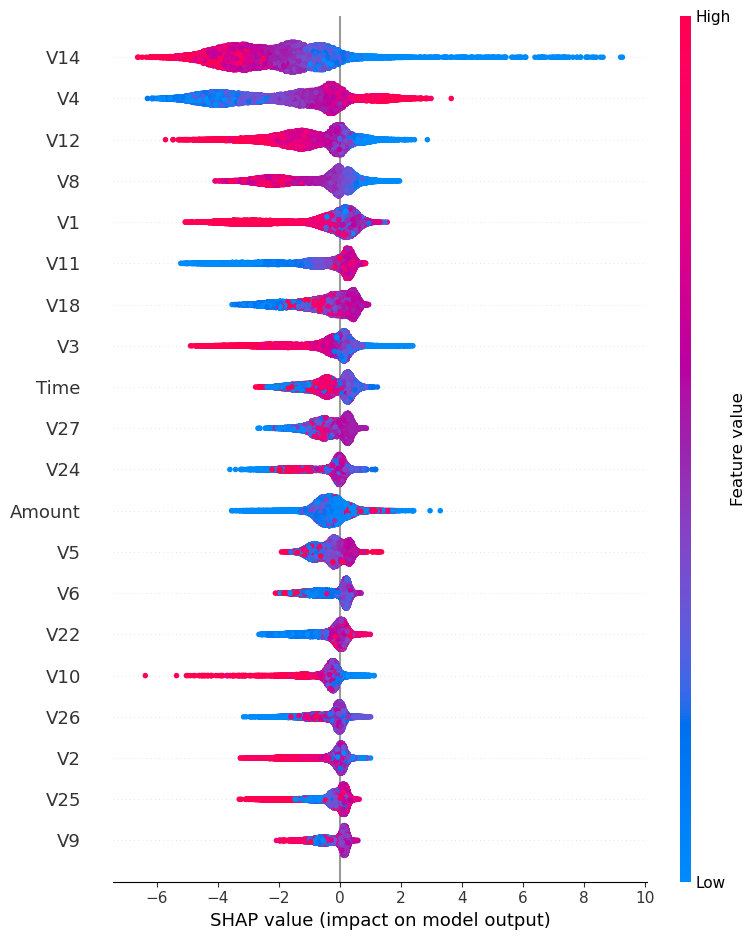

In [41]:
model = xgb.XGBClassifier().fit(my_xtrain_samp,my_ytrain_samp)
explainer  = shap.TreeExplainer(model)
shap_val = explainer.shap_values(myxtestt)
shap.summary_plot(shap_val,myxtestt)

In [47]:
np.shape(shap_val)

(242085, 30)

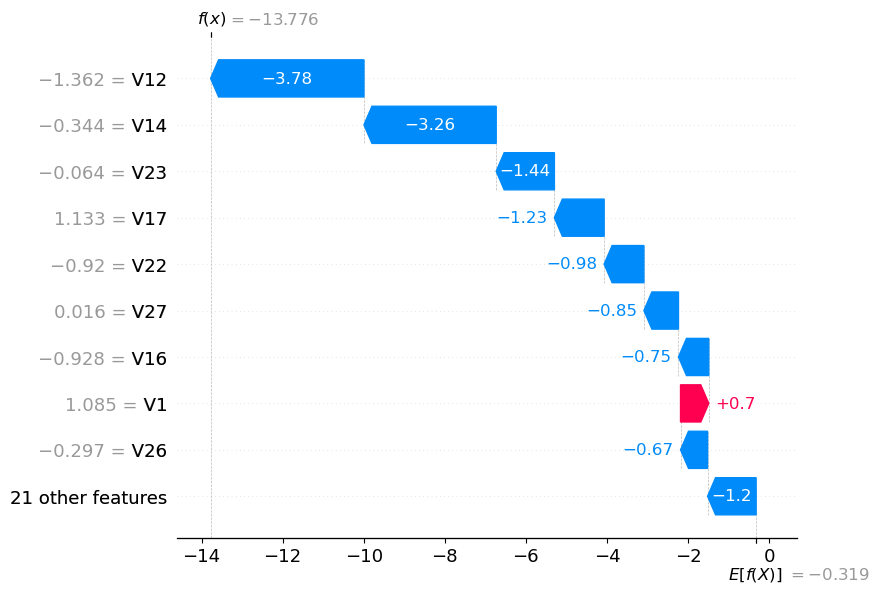

In [51]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_val[0],  # SHAP values for first prediction
        base_values=explainer.expected_value,  # Expected value
        data=myxtestt.iloc[0],  # Feature values for first prediction
        feature_names=myxtestt.columns.tolist()
    ))

* even with scaler game thory of the features attrebuites doesnt change if they all meant to scale properly

# final result

* based on our complex PCA data we tried to feature engeering to make un balanced data with diffrenet model to better data and it seems consider the ratio of it was best idea to we actually predict 


* next step right away we go for scale our data we had alot of version for example standard scaler man mix scaler but we decide the SMOTE BASED on we ar dealing with fruad detection and unbalance class in range of 0 and 1 

* thinking about what features reduce dimonsion was better is hard because they bunch of number that are cread of principal component analyst so by SHAP XGBOOST classifier can be good variant to we see what features columns play crucial roles 

* choose model here are so wildly open from enasamblers like xgboost or catboost or randomforest to the linear models and svm but we need to remember which one actually needs to scale and which one doesnt needs too

* using SHAP to give use more information about features and if its needs ti we change them eb=ven they are PCA 

* and in the end this workflow will be iteration until we take our evaluation goal 
* best model due to time usage and overall -> logistic regression with overal good F1 score and AOC-AUC